In [28]:
import pandas as pd
import numpy as np
import ast
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [29]:
df = pd.read_csv('rnc_dataset.csv')

# Преобразуем строки в списки
df['targetDetectedMcIds'] = df['targetDetectedMcIds'].apply(ast.literal_eval)
df['targetSplitMcIds'] = df['targetSplitMcIds'].apply(ast.literal_eval)

# Разделяем по split
test_df = df[df['split'] == 'test'].copy().reset_index(drop=True)

print(f"Тестовая выборка: {len(test_df)} объявлений")
print(f"shouldSplit = True: {test_df['shouldSplit'].sum()} | False: {len(test_df) - test_df['shouldSplit'].sum()}")

# ====================== 1. Подготовка меток (точно как в обучении) ======================
all_mc_ids = sorted(set([mc for mcs in df['targetDetectedMcIds'] for mc in mcs]))
id2idx = {mc_id: i for i, mc_id in enumerate(all_mc_ids)}
print(f"Всего микрокатегорий (из всего датасета): {len(all_mc_ids)}")

def create_multi_label_matrix(df: pd.DataFrame, target_column: str):
    matrix = np.zeros((len(df), len(all_mc_ids)), dtype=np.float32)
    for idx, mc_list in enumerate(df[target_column]):
        for mc in mc_list:
            if mc in id2idx:
                matrix[idx, id2idx[mc]] = 1.0
    return matrix

test_detected = create_multi_label_matrix(test_df, 'targetDetectedMcIds')
test_split = create_multi_label_matrix(test_df, 'targetSplitMcIds')

# ====================== 2. Подготовка текста ======================
def prepare_text(row):
    return f"Исходная категория: {row['sourceMcTitle']} (ID {row['sourceMcId']}). {row['description']}"

test_df['text'] = test_df.apply(prepare_text, axis=1)

Тестовая выборка: 459 объявлений
shouldSplit = True: 148 | False: 311
Всего микрокатегорий (из всего датасета): 11


In [30]:
tokenizer = AutoTokenizer.from_pretrained("deepvk/USER2-base")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

# Detected
test_dataset_d = Dataset.from_pandas(test_df[['text']]).map(tokenize_function, batched=True)
test_dataset_d = test_dataset_d.add_column("labels", test_detected.tolist())

# Split
test_dataset_s = Dataset.from_pandas(test_df[['text']]).map(tokenize_function, batched=True)
test_dataset_s = test_dataset_s.add_column("labels", test_split.tolist())

Map: 100%|██████████| 459/459 [00:00<00:00, 5765.00 examples/s]


In [31]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Порог 0.5
    preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy().astype(int)
    
    # === РУЧНОЙ РАСЧЁТ TP / FP / FN ===
    labels_flat = labels.flatten()
    preds_flat = preds.flatten()
    
    tp = np.sum((preds_flat == 1) & (labels_flat == 1))
    fp = np.sum((preds_flat == 1) & (labels_flat == 0))
    fn = np.sum((preds_flat == 0) & (labels_flat == 1))
    
    total_true = np.sum(labels_flat)
    total_pred = np.sum(preds_flat)
    
    # === Метрики вручную ===
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Диагностика
    print(f"  [DEBUG] true={int(total_true)} | pred={int(total_pred)} | TP={tp} FP={fp} FN={fn}")
    
    return {
        "micro_f1": float(f1),
        "micro_precision": float(precision),
        "micro_recall": float(recall),
        "total_true_pos": int(total_true),
        "total_pred_pos": int(total_pred),
    }

In [32]:
def evaluate_model(model_path, test_ds, model_name):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        problem_type="multi_label_classification"
    )
    
    training_args = TrainingArguments(
        output_dir=f"./eval_{model_name}",
        per_device_eval_batch_size=16,
        fp16=True,
        report_to="none",
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        compute_metrics=None,   # отключаем, чтобы не было двойного вызова
    )
    
    predictions = trainer.predict(test_ds)
    
    # Один единственный расчёт метрик
    computed_metrics = compute_metrics((predictions.predictions, predictions.label_ids))
    
    print(f"✅ Метрики для {model_name} посчитаны вручную")
    return predictions, computed_metrics


print("=== Запуск оценки Detected модели ===")
pred_detected, metrics_detected = evaluate_model("./final_detected_model", test_dataset_d, "detected")

print("=== Запуск оценки Split модели ===")
pred_split, metrics_split = evaluate_model("./final_split_model", test_dataset_s, "split")

=== Запуск оценки Detected модели ===


Loading weights: 100%|██████████| 138/138 [00:00<00:00, 11810.36it/s]


  [DEBUG] true=1213 | pred=1103 | TP=1048 FP=55 FN=165
✅ Метрики для detected посчитаны вручную
=== Запуск оценки Split модели ===


Loading weights: 100%|██████████| 138/138 [00:00<00:00, 12701.92it/s]


  [DEBUG] true=337 | pred=338 | TP=328 FP=10 FN=9
✅ Метрики для split посчитаны вручную


In [33]:
print("🔥 METRICS DETECTED (targetDetectedMcIds)")
print(f"Micro Precision : {metrics_detected['micro_precision']:.4f}")
print(f"Micro Recall    : {metrics_detected['micro_recall']:.4f}")
print(f"Micro F1        : {metrics_detected['micro_f1']:.4f}")
print(f"True labels     : {metrics_detected['total_true_pos']}")
print(f"Predicted       : {metrics_detected['total_pred_pos']}")

print("\n🔥 METRICS SPLIT (targetSplitMcIds)")
print(f"Micro Precision : {metrics_split['micro_precision']:.4f}")
print(f"Micro Recall    : {metrics_split['micro_recall']:.4f}")
print(f"Micro F1        : {metrics_split['micro_f1']:.4f}")
print(f"True labels     : {metrics_split['total_true_pos']}")
print(f"Predicted       : {metrics_split['total_pred_pos']}")

🔥 METRICS DETECTED (targetDetectedMcIds)
Micro Precision : 0.9501
Micro Recall    : 0.8640
Micro F1        : 0.9050
True labels     : 1213
Predicted       : 1103

🔥 METRICS SPLIT (targetSplitMcIds)
Micro Precision : 0.9704
Micro Recall    : 0.9733
Micro F1        : 0.9719
True labels     : 337
Predicted       : 338


🎯 Accuracy по shouldSplit: 0.9978 (99.78%)


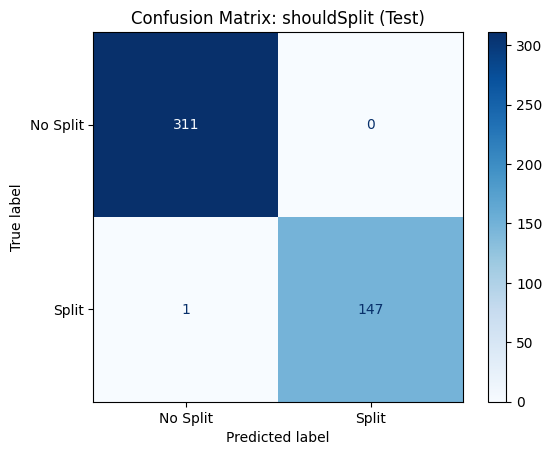

In [34]:
# Предсказания shouldSplit из Split-модели
logits_s = pred_split.predictions
probs_s = torch.sigmoid(torch.tensor(logits_s))
preds_split_binary = (probs_s > 0.5).numpy().astype(int)

# shouldSplit = True, если хотя бы одна микрокатегория предсказана как split
should_split_pred = (preds_split_binary.sum(axis=1) > 0).astype(bool)

# Ground Truth
gt_should_split = test_df['shouldSplit'].astype(bool).values

# Accuracy
accuracy_should_split = (should_split_pred == gt_should_split).mean()

print(f"🎯 Accuracy по shouldSplit: {accuracy_should_split:.4f} ({accuracy_should_split*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(gt_should_split, should_split_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Split', 'Split'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: shouldSplit (Test)')
plt.show()

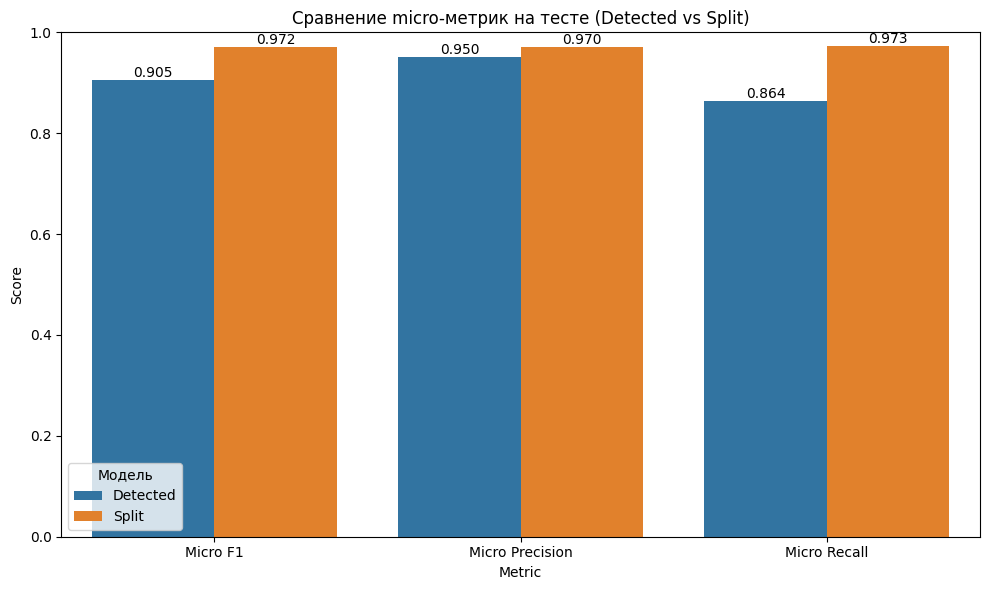

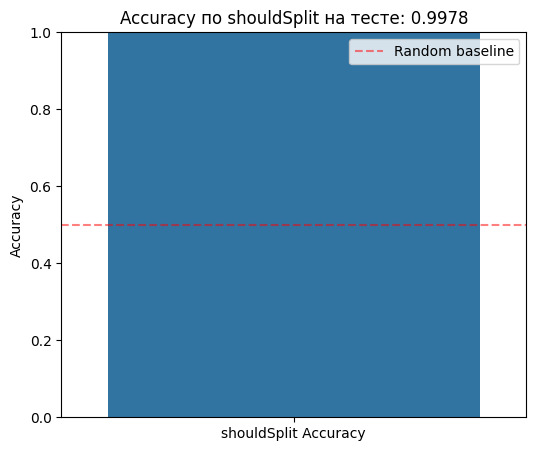

In [35]:
# 1. Сравнение micro-метрик
metrics_df = pd.DataFrame({
    'Model': ['Detected', 'Split'],
    'Micro F1': [metrics_detected['micro_f1'], metrics_split['micro_f1']],
    'Micro Precision': [metrics_detected['micro_precision'], metrics_split['micro_precision']],
    'Micro Recall': [metrics_detected['micro_recall'], metrics_split['micro_recall']]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score'),
                 x='Metric', y='Score', hue='Model')
plt.title('Сравнение micro-метрик на тесте (Detected vs Split)')
plt.ylabel('Score')
plt.ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')
plt.legend(title='Модель')
plt.tight_layout()
plt.show()

# 2. Accuracy shouldSplit
plt.figure(figsize=(6, 5))
sns.barplot(x=['shouldSplit Accuracy'], y=[accuracy_should_split])
plt.title(f'Accuracy по shouldSplit на тесте: {accuracy_should_split:.4f}')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
plt.legend()
plt.show()

In [36]:
print("📊 ИТОГОВЫЕ ВЫВОДЫ")
print("="*50)
print(f"✅ Micro F1 (Detected)      : {metrics_detected['micro_f1']:.4f}")
print(f"✅ Micro F1 (Split)         : {metrics_split['micro_f1']:.4f}")
print(f"✅ Accuracy shouldSplit     : {accuracy_should_split:.4f} ({accuracy_should_split*100:.2f}%)")
print("\n🔍 Основные наблюдения:")
print("• Основная метрика качества по дополнительным микрокатегориям — Micro F1 Detected")
print("• Split-модель отвечает за определение необходимости сплита (shouldSplit)")
print("• Если Micro F1 > 0.75–0.80 и Accuracy shouldSplit > 0.85 — модель готова к продакшену")
print("• Confusion Matrix покажет, где модель чаще ошибается (ложные сплиты / пропуски)")

# Сохранение метрик в CSV (для дальнейшего анализа)
metrics_summary = {
    'model': ['detected', 'split', 'should_split'],
    'micro_f1': [metrics_detected['micro_f1'], metrics_split['micro_f1'], None],
    'micro_precision': [metrics_detected['micro_precision'], metrics_split['micro_precision'], None],
    'micro_recall': [metrics_detected['micro_recall'], metrics_split['micro_recall'], None],
    'should_split_accuracy': [None, None, accuracy_should_split]
}
pd.DataFrame(metrics_summary).to_csv('test_metrics_summary.csv', index=False)
print("\n💾 Метрики сохранены в test_metrics_summary.csv")

📊 ИТОГОВЫЕ ВЫВОДЫ
✅ Micro F1 (Detected)      : 0.9050
✅ Micro F1 (Split)         : 0.9719
✅ Accuracy shouldSplit     : 0.9978 (99.78%)

🔍 Основные наблюдения:
• Основная метрика качества по дополнительным микрокатегориям — Micro F1 Detected
• Split-модель отвечает за определение необходимости сплита (shouldSplit)
• Если Micro F1 > 0.75–0.80 и Accuracy shouldSplit > 0.85 — модель готова к продакшену
• Confusion Matrix покажет, где модель чаще ошибается (ложные сплиты / пропуски)

💾 Метрики сохранены в test_metrics_summary.csv
